#NLU - Assignment 2 - Sanskrit to English NMT
###Name: Arijit Chakraborty
###Roll No: G25AIT1031

The purpose of this assignment is to build and evaluate a Neural Machine Translation system which can translate Sanskrit — a low-resource, morphologically rich language — into English,  a fine-tuned pretrained multilingual model, and to assess translation quality using BLEU, BERTScore, and computational efficiency metrics.

###Setup and Package Installation

In the first block, I will get the system ready by downloading all external libraries. I'm putting transformers by huggingface for the model pipeline, sentencepiece for the tokenizer engine, accelerate for the device handling optimizations, and bert-score for future language evaluation.

In [28]:
###I need to install transformers, sentencepiece, accelerate, and bert-score first###
!pip install -q transformers sentencepiece accelerate bert-score
###Importing requried modules###
import os
import time
import math
import random
import pandas as pan
import numpy as num
import torch
import torch.nn as net
from torch.utils.data import Dataset,DataLoader
from transformers import AutoTokenizer,AutoModelForSeq2SeqLM,get_linear_schedule_with_warmup
import nltk
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plot
import re
from bert_score import score as calcBert

###Environment Configuration

This part takes care of environment settings and device registration for our network training to work reliably. I set the internal random seeds for python, numpy and torch every time the script runs so that our results remain reproducible. The code then automatically scans the machine in runtime to check for the presence of GPU.

In [30]:
###Setting a random seed to keep results consistent###
seedVal=42
random.seed(seedVal)
num.random.seed(seedVal)
torch.manual_seed(seedVal)
deviceType = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Checking device:")
print(deviceType)
if deviceType.type=='cuda':
    print("GPU found ")
    print(torch.cuda.get_device_name(0))
else:
    print("No GPU found. Make sure to turn on GPU mode.")


Checking device:
cuda
GPU found 
NVIDIA A100-SXM4-40GB


###Helper Functions and Custom Classes

In this code below I build up core code frameworks and algorithmic helpers before we start data feeding. I am creating functions that merge raw spreadsheets, calculate the number of active trainable parameters, take care of custom train and test text collators, run multi-mode optimizations per epoch, split texts with regex, etc. I have defined a class, which is our custom data loader wrapper class that formats our sequence arrays properly for feeding them to the processor loops.

In [31]:
###funtion to load and merge raw data###
def LoadAndMergePairs(saPath,enPath):
    saData=pan.read_csv(saPath,encoding='utf-8-sig')
    enData=pan.read_csv(enPath,encoding='utf-8-sig')
    mergedDf=pan.merge(saData,enData,on='Source_id',how= 'inner')
    mergedDf=mergedDf.dropna(subset=['Sentence_sa','Sentence_en']).reset_index(drop=True)
    return mergedDf
###function to count weights that need training###
def CountModelParams(modelObj):
    return sum(p.numel() for p in modelObj.parameters() if p.requires_grad)

###Custom dataset class for translation tasks###
class NllbTranslationDataset(Dataset):
    ###Sets up datasets with text arrays###
    def __init__(self,dataFrame,hasTarget=True):
        self.rowIds = dataFrame['Source_id'].tolist()
        self.srcTexts = dataFrame['Sentence_sa'].astype(str).tolist()
        self.hasTarget = hasTarget
        if hasTarget:
            self.tgtTexts =dataFrame['Sentence_en'].astype(str).tolist()
    ###Returns count of input sentences###
    def __len__(self):
        return len(self.srcTexts)
    ###Grabs one parallel sequence row###
    def __getitem__(self,idx):
        if self.hasTarget:
            return self.srcTexts[idx],self.tgtTexts[idx],self.rowIds[idx]
        return self.srcTexts[idx],self.rowIds[idx]

###function to tokenise both sides for our training loop###
def CollateTrainBatch(batchData):
    srcList,tgtList,idList=zip(*batchData)
    globalTokenizer.src_lang = srcLangCode
    globalTokenizer.tgt_lang = tgtLangCode
    modelInputs=globalTokenizer(text=list(srcList),text_target=list(tgtList),truncation=True,max_length=maxSeqLen,padding=True,return_tensors="pt")
    labelIds=modelInputs["labels"]
    labelIds[labelIds== globalTokenizer.pad_token_id]=-100
    modelInputs["labels"] =labelIds
    return modelInputs,idList
###function to tokenize inputs only since we predict###
def CollateInferBatch(batchData):
    srcList,idList = zip(*batchData)
    globalTokenizer.src_lang = srcLangCode
    modelInputs=globalTokenizer(list(srcList),truncation=True,max_length=maxSeqLen,padding=True,return_tensors ="pt")
    return modelInputs,idList
###Running trainng or validation loops here###
def RunSingleEpoch(dataLoader,isTrainMode= True):
    globalModel.train(isTrainMode)
    totalLoss,batchCount =0.0,0
    for batchInputs,_ in dataLoader:
        batchInputs = {k:v.to(deviceType) for k,v in batchInputs.items()}
        if isTrainMode:
            globalOptimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(deviceType.type=='cuda')):
                modelOutputs =globalModel(**batchInputs)
                lossValue = modelOutputs.loss
            ampScaler.scale(lossValue).backward()
            ampScaler.unscale_(globalOptimizer)
            torch.nn.utils.clip_grad_norm_(globalModel.parameters(),maxGradNorm)
            ampScaler.step(globalOptimizer)
            ampScaler.update()
            lrScheduler.step()
        else:
            with torch.no_grad(),torch.cuda.amp.autocast(enabled=(deviceType.type=='cuda')):
                modelOutputs = globalModel(**batchInputs)
                lossValue =modelOutputs.loss
        totalLoss +=lossValue.item()
        batchCount += 1
    return totalLoss/batchCount
###function to split standard english into regex tokens###
def TokenizeEnglishText(rawText):
    tokenPattern=re.compile(r"[A-Za-z]+|[0-9]+|[^\sA-Za-z0-9]")
    return tokenPattern.findall(str(rawText).strip().lower())

###Dataset Assembly and Loading Data

The code snippet below is to gather the parallel textual rows from the local folder directory here. I start by running a quick safety check to see if the six component bits of the spreadshet are on the disk. This is to prevent the script crashing. After the verification process I use personalised merging helper to merge the source language and target language columns that have been created by mapping the indices of the unique identifir.

In [32]:
###Defining data path###
###This must be changed based on the locatin of the data files###
dataDirectory="./nmt_data"
requiredFilesList=["train_sa_10000.csv","train_en_10000.csv","dev_sa_1000.csv","dev_en_1000.csv","test_sa_1000.csv","test_en_1000.csv"]
missingFilesList = [f for f in requiredFilesList if not os.path.exists(os.path.join(dataDirectory,f))]
if missingFilesList:
    print("Files missing:")
    print(missingFilesList)
else:
    print("found all data files")
###Running my data loader function here###
trainDf =LoadAndMergePairs(f"{dataDirectory}/train_sa_10000.csv",f"{dataDirectory}/train_en_10000.csv")
devDf = LoadAndMergePairs(f"{dataDirectory}/dev_sa_1000.csv",f"{dataDirectory}/dev_en_1000.csv")
testDf =LoadAndMergePairs(f"{dataDirectory}/test_sa_1000.csv",f"{dataDirectory}/test_en_1000.csv")
print("Data counts:")
print("Train rows:",len(trainDf))
print("Dev rows:",len(devDf))
print("Test rows:",len(testDf))

found all data files
Data counts:
Train rows: 10000
Dev rows: 1000
Test rows: 1000


###Initializing the Translation Model

In this section I am loading the container robust lingustic architecture from Meta via the HuggingFace internet hub. I opted for the NLLB model that has 600 million parameters along with a vocabulary tracker, deploying Sanskrit as the input native and standard English as the output result.

In [33]:
###pretrained model being used is facebook/nllb-200-distilled-600M###
pretrainedModelName = "facebook/nllb-200-distilled-600M"
srcLangCode ="san_Deva"
tgtLangCode ="eng_Latn"
###Pulling the setup confg from HuggingFace dirctly###
globalTokenizer= AutoTokenizer.from_pretrained(pretrainedModelName,src_lang=srcLangCode,tgt_lang=tgtLangCode)
globalModel= AutoModelForSeq2SeqLM.from_pretrained(pretrainedModelName).to(deviceType)
totalParamsCount= CountModelParams(globalModel)
print("Total parameters we can train:")
print(totalParamsCount)
try:
    forcedBosTokenId =globalTokenizer.convert_tokens_to_ids(tgtLangCode)
except Exception:
    forcedBosTokenId =globalTokenizer.lang_code_to_id[tgtLangCode]
print("Target language start token ID:")
print(forcedBosTokenId)

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Total parameters we can train:
615073792
Target language start token ID:
256047


###Formatting Batches and Data Iterators

This section acts as a bridge that takes raw columns to a network without overloding the processing hardware memory. Initially custom datasets are generated for the individual steps and feed them into Pytorch's multithreaded dataloaders directly. If I set the input length boundary to 128 tokens and batch sentences in small clusters of 16 I can loop through the language content during the optimisation and inference pases.

In [34]:
maxSeqLen = 128
batchSizeVal = 16
###Initializing custom data sets###
trainDataset =NllbTranslationDataset(trainDf,hasTarget=True)
devDataset =NllbTranslationDataset(devDf,hasTarget=True)
testDataset =NllbTranslationDataset(testDf,hasTarget=False)
###Setting up our iterators with custom collate logic###
trainLoader =DataLoader(trainDataset, batch_size=batchSizeVal,shuffle=True,collate_fn=CollateTrainBatch)
devLoader =DataLoader(devDataset, batch_size=batchSizeVal,shuffle=False,collate_fn=CollateTrainBatch)
testLoader =DataLoader(testDataset, batch_size=batchSizeVal,shuffle=False,collate_fn=CollateInferBatch)
print("Batch counts ready:")
print("Train batches:",len(trainLoader))
print("Dev batches:",len(devLoader))
print("Test batches:",len(testLoader))

Batch counts ready:
Train batches: 625
Dev batches: 63
Test batches: 63


###Model Fine-tuning Optimization Pass

This part is for an extensive learning process where the model will learn based on our example through 4 passes. I developed an AdamW solver with a mixed-precision gradient scaling technique to accelerate complex mathematics while protecting against mis calculations of network components. The code checks the performanc of our validation text after each round, saves the best checkpoint configuration automatically, and applies an early stop if scores do not improve.


In [35]:
###Setting up hyperprameters###
totalEpochs = 10
learningRateVal = 2e-5
weightDecayVal= 0.01
maxGradNorm = 1.0
earlyStopPatienceLimit =2
checkpointSaveDir = "/content/nllb_best"
os.makedirs(checkpointSaveDir, exist_ok=True)
globalOptimizer=torch.optim.AdamW(globalModel.parameters(), lr=learningRateVal, weight_decay=weightDecayVal)
totalTrainingSteps =len(trainLoader)*totalEpochs
lrScheduler= get_linear_schedule_with_warmup(globalOptimizer,num_warmup_steps =int(0.1*totalTrainingSteps), num_training_steps=totalTrainingSteps)
ampScaler= torch.cuda.amp.GradScaler(enabled=(deviceType.type=='cuda'))
bestDevLossValue =float('inf')
epochsWithoutImprovementCount=0
trainingHistoryLog={'train_loss':[],'dev_loss':[]}
###Starting the main loop now###
for currentEpoch in range(1,totalEpochs+1):
    epochStartTime = time.time()
    currentTrainLoss = RunSingleEpoch(trainLoader,isTrainMode=True)
    currentDevLoss =RunSingleEpoch(devLoader,isTrainMode=False)
    epochElapsedTime = time.time()-epochStartTime
    trainingHistoryLog['train_loss'].append(currentTrainLoss)
    trainingHistoryLog['dev_loss'].append(currentDevLoss)
    statusMarker = ""
    if currentDevLoss < bestDevLossValue-1e-4:
        bestDevLossValue =currentDevLoss
        epochsWithoutImprovementCount= 0
        ###I want to save my progress here###
        globalModel.save_pretrained(checkpointSaveDir)
        globalTokenizer.save_pretrained(checkpointSaveDir)
        statusMarker= "  <- checkpoint saved!"
    else:
        epochsWithoutImprovementCount +=1
    currentLrRate=globalOptimizer.param_groups[0]['lr']
    print(f"Epoch {currentEpoch} done in {epochElapsedTime:.1f}s")
    print(f"Train Loss: {currentTrainLoss:.4f} | Dev Loss: {currentDevLoss:.4f}")
    if statusMarker:
        print(statusMarker)
    if epochsWithoutImprovementCount>=earlyStopPatienceLimit:
        print("Stopping early because loss stopped getting better.")
        break
print("Finished training. Loading our best model weights back in.")
globalModel=AutoModelForSeq2SeqLM.from_pretrained(checkpointSaveDir).to(deviceType)

/tmp/ipykernel_1460/2182308542.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  ampScaler= torch.cuda.amp.GradScaler(enabled=(deviceType.type=='cuda'))
/tmp/ipykernel_1460/2775080104.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(deviceType.type=='cuda')):
/tmp/ipykernel_1460/2775080104.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(),torch.cuda.amp.autocast(enabled=(deviceType.type=='cuda')):


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1 done in 103.9s
Train Loss: 1.9674 | Dev Loss: 1.5960
  <- checkpoint saved!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2 done in 101.8s
Train Loss: 1.5939 | Dev Loss: 1.4708
  <- checkpoint saved!


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 5 done in 101.5s
Train Loss: 1.2068 | Dev Loss: 1.3933
  <- checkpoint saved!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 6 done in 102.0s
Train Loss: 1.1375 | Dev Loss: 1.3864
  <- checkpoint saved!
Epoch 7 done in 101.5s
Train Loss: 1.0840 | Dev Loss: 1.3884
Epoch 8 done in 101.7s
Train Loss: 1.0465 | Dev Loss: 1.3888
Stopping early because loss stopped getting better.
Finished training. Loading our best model weights back in.


Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

###Visualizing Loss History

This block alters the logs saved during the training loop into a user-friendly visual graph without any hassle. I plot the progression of training loss against their validation loss values. It does a quick diagnostic check for me to confirm that the model error is steadily coming down and not severely overfitting.

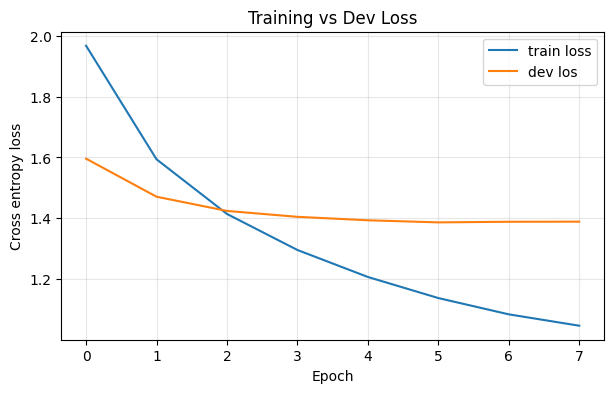

In [36]:
###I am plotting the training curves###
plot.figure(figsize=(7,4))
plot.plot(trainingHistoryLog['train_loss'] ,label='train loss')
plot.plot(trainingHistoryLog['dev_loss'], label='dev los')
plot.xlabel('Epoch')
plot.ylabel('Cross entropy loss')
plot.title('Training vs Dev Loss')
plot.legend()
plot.grid(alpha=0.3)
plot.show()

###Translating the Test Sequences

With the network optimized I put it into evaluation mode and use it to translate the other evaluation rows. I introduce a 5 beam search method within a safe block that disables weight updates. Text strings are generated which can be decoded from internal tokens to English language text. We wrap the newly translated sentences with their respective tracking index in a dataframe spreadsheet.

In [37]:
###predicting translations for test sentences###
beamSearchSize = 5
maxGeneratedLength = 60
globalModel.eval()
testIdsAccumulator,testPredictionsAccumulator=[],[]
if deviceType.type =='cuda':
    torch.cuda.synchronize()
inferenceStartTime= time.time()
###Starting the generation pass###
with torch.no_grad():
    for batchInputs,batchIds in testLoader:
        batchInputs ={k:v.to(deviceType) for k, v in batchInputs.items()}
        generatedTokens =globalModel.generate(**batchInputs, forced_bos_token_id=forcedBosTokenId, num_beams=beamSearchSize,max_length=maxGeneratedLength)
        decodedSentences =globalTokenizer.batch_decode(generatedTokens,skip_special_tokens=True)
        testPredictionsAccumulator.extend(decodedSentences)
        testIdsAccumulator.extend(batchIds)
if deviceType.type=='cuda':
    torch.cuda.synchronize()
totalInferenceDuration=time.time()-inferenceStartTime
print("Inference finshed!")
print("Total time in second:",totalInferenceDuration)
###Organizing everything into my final submission dataframe###
submissionOutputDf =pan.DataFrame({'Source_id':testIdsAccumulator,'Sentence_en':testPredictionsAccumulator})
submissionOutputDf =submissionOutputDf.sort_values('Source_id').reset_index(drop=True)
submissionOutputDf.to_csv('/content/submission.csv',index= False,encoding='utf-8')
print("Saved the submission file to disk.")

Inference finshed!
Total time in second: 50.76367163658142
Saved the submission file to disk.


###Benchmarks Calculation and Run Summary

In this block, I analyze both the translation accuracy and the performance results. I match the sequences of my prediction text with references in the hidden baseline, resulting in the tokenization of raw words. I then evaluate using standard translation benchmarks: the word-overlap BLEU score and the semantic-similarity BERTScore thus producing a summary report that outputs the parameters I used, time taken, number of sentences and overall accuracy scores.

In [38]:
###calculating and logging final metrics###
goldTargetsMap = dict(zip(testDf['Source_id'], testDf['Sentence_en']))
predictedTargetsMap =dict(zip(submissionOutputDf['Source_id'],submissionOutputDf['Sentence_en']))
sharedRowIds = [sid for sid in goldTargetsMap if sid in predictedTargetsMap]
goldStandardTexts = [goldTargetsMap[sid] for sid in sharedRowIds]
predictedOutputsTexts =[predictedTargetsMap[sid] for sid in sharedRowIds]
###Tokenizing text into list of word streams###
goldTokenizedLists= [[TokenizeEnglishText(ref)] for ref in goldStandardTexts]
predictedTokenizedLists =[TokenizeEnglishText(hyp) for hyp in predictedOutputsTexts]
###Calculating standard translation benchmarks###
calculatedBleuScore= corpus_bleu(goldTokenizedLists,predictedTokenizedLists)
###Computing semantic similarity via BERTScore###
precisionMetrics, recallMetrics,f1Scores= calcBert(predictedOutputsTexts,goldStandardTexts,lang='en',rescale_with_baseline = True, verbose = False,device =deviceType.type)
meanF1Score=f1Scores.mean().item()
print("Evaluaton Scores Complete")
print("BLEU Score:",calculatedBleuScore)
print("BERTScore F1:",meanF1Score)
###building side-by-side table to eyeball predictions vs gold###
comparisonRows=[]
for sid in sharedRowIds[:10]:
    comparisonRows.append({
        'Source_id': sid,
        'Sanskrit': testDf.loc[testDf['Source_id']==sid,'Sentence_sa'].values[0],
        'Gold_Reference':goldTargetsMap[sid],
        'Model_Prediction':predictedTargetsMap[sid]
    })
comparisonDf=pan.DataFrame(comparisonRows)
pan.set_option('display.max_colwidth',None)
print(comparisonDf.to_string(index=False))
###I am printing out final log metrics###
print("FINAL RUN RESULTS")
print("Model name used:",pretrainedModelName)
print("Total model weight trained:",totalParamsCount)
print("Sentence translated:",len(testIdsAccumulator))
print("Total generation time:",totalInferenceDuration,"seconds")
print("Final BLEU accuracy:",calculatedBleuScore)
print("Final BERTScore accuracy:",meanF1Score)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluaton Scores Complete
BLEU Score: 0.3296325424410947
BERTScore F1: 0.6330817341804504
 Source_id                                                                                                                                        Sanskrit                                                                                                                                       Gold_Reference                                                                                                                    Model_Prediction
         1                                                                                  एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।                                                                                                Eclipse also helps the programmer to find out errors.                                                                                   It also helps in troubleshooting Eclipse program.
         2 विश्वासकारणादेव समभाषि मया 